# 肺部X光图像分割 - U-Net训练

本Notebook使用Kaggle数据集 [Chest X-Ray Lungs Segmentation](https://www.kaggle.com/datasets/iamtapendu/chest-x-ray-lungs-segmentation/data) 训练一个U-Net模型进行肺部区域分割。

In [6]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.transforms import functional as nnfun

import torch.nn.functional as nnfun

from tqdm import tqdm  

# 设置随机种子以保证可重复性
torch.manual_seed(42)
np.random.seed(42)

## 1. 数据集定义

In [7]:
class LungSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, mask_transform=None, image_size=(256, 256)):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size
        self.transform = transform
        self.mask_transform = mask_transform

        # 获取所有图像文件名
        image_files = sorted(os.listdir(image_dir))
        mask_files = sorted(os.listdir(mask_dir))

        # 基于文件名核心部分进行匹配
        self.pairs = []
        for img_f in image_files:
            base = os.path.splitext(img_f)[0]
            matched_mask = [m for m in mask_files if m.startswith(base)]
            if len(matched_mask) == 1:
                self.pairs.append((img_f, matched_mask[0]))
            else:
                print(f"警告: 图像 {img_f} 在 mask 文件夹中未找到唯一匹配，跳过")

        print(f"成功匹配 {len(self.pairs)} 对图像-掩码")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.pairs[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        try:
            # 打开图像（灰度图）
            image = Image.open(img_path).convert('L')
            mask = Image.open(mask_path).convert('L')
        except Exception as e:
            print(f"错误: 无法读取文件 {img_path} 或 {mask_path}: {e}")
            raise e

        # 缩放到统一尺寸
        image = image.resize(self.image_size, Image.BILINEAR)
        mask = mask.resize(self.image_size, Image.NEAREST)  # 保持二值性

        # 应用数据增强（如果有）
        if self.transform:
            # 为保证图像和掩码的几何变换一致，使用相同的随机种子
            seed = torch.randint(0, 2**32, (1,)).item()
            torch.manual_seed(seed)
            image = self.transform(image)
            torch.manual_seed(seed)
            mask = self.mask_transform(mask) if self.mask_transform else mask

        # 转换为 numpy 并归一化
        image = np.array(image, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)  # 二值化

        # 转为 tensor，添加通道维度
        image = torch.tensor(image).unsqueeze(0)  # [1, H, W]
        mask = torch.tensor(mask).unsqueeze(0)    # [1, H, W]

        return image, mask

## 2.1 模型定义

In [8]:
class DoubleConv(nn.Module):
    """(Conv3x3 -> BN -> ReLU) x 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """下采样：MaxPool + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """上采样：双线性插值（或转置卷积） + 跳跃连接 + DoubleConv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
        
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # 处理可能的尺寸差异（通过裁剪）
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                    diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class STN(nn.Module):
    def __init__(self, in_channels=1, output_size=(256, 256)):
        super(STN, self).__init__()
        self.output_size = output_size
        # 定位网络：卷积层 -> 全连接层 -> 6个参数
        self.localization = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.Conv2d(8, 10, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(10),
            nn.ReLU(True),
            nn.Conv2d(10, 12, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(12),
            nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),   # 输出 [B, 12, 1, 1]
        )
        # 计算输入经过卷积后的空间尺寸，用于全连接层输入维度
        # 由于使用了AdaptiveAvgPool2d(1)，全连接输入固定为12
        self.fc_loc = nn.Sequential(
            nn.Linear(12, 32),
            nn.ReLU(True),
            nn.Linear(32, 6)
        )
        # 初始化仿射参数为恒等变换
        self.fc_loc[-1].weight.data.zero_()
        self.fc_loc[-1].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))

    def forward(self, x):
        # x shape: (B, C, H, W)
        bs = x.size(0)
        # 通过定位网络获取仿射参数
        loc_feat = self.localization(x).view(bs, -1)  # (B, 12)
        theta = self.fc_loc(loc_feat)                 # (B, 6)
        theta = theta.view(bs, 2, 3)                  # 2x3仿射矩阵
        # 生成采样网格
        grid = nnfun.affine_grid(theta, x.size(), align_corners=True)
        # 采样得到变换后的图像
        x_transformed = nnfun.grid_sample(x, grid, align_corners=True)
        return x_transformed

class UNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=1, bilinear=True, use_stn=True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        self.use_stn = use_stn

        if self.use_stn:
            self.stn = STN(in_channels=n_channels)

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        if self.use_stn:
            x = self.stn(x)
        # 空间变换
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

## 3. 训练配置

In [9]:
# 定义训练集数据增强
train_image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
])

# 掩码只需几何变换（不需要颜色调整），这里直接复用几何变换部分
# 为简化，我们可以使用相同的 transform，但注意掩码不应做颜色调整
# 所以单独定义一个只包含几何变换的 transform
train_mask_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
])

# 数据路径（根据实际存放位置修改）
IMAGE_DIR = "./archive_2/Chest-X-Ray/image"
MASK_DIR = "./archive_2/Chest-X-Ray/mask"

# 训练参数
BATCH_SIZE = 8
EPOCHS = 75
LEARNING_RATE = 1e-3
IMAGE_SIZE = (256, 256)   # 输入图像统一尺寸
VAL_SPLIT = 0.2            # 20%作为验证集
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {DEVICE}")
EARLY_STOPPING_PATIENCE = 10  # 耐心值，即连续多少个 epoch 验证集指标没有提升后停止训练

# 保存模型路径
SAVE_PATH = "./saved_models/unet_stn_lungs_segmentation.pth"

使用设备: cuda


## 4. 准备数据

In [10]:
# 创建数据集：训练集使用增强，验证集不使用
train_dataset = LungSegmentationDataset(
    IMAGE_DIR, MASK_DIR, 
    transform=train_image_transform, 
    mask_transform=train_mask_transform,
    image_size=IMAGE_SIZE
)

val_dataset = LungSegmentationDataset(
    IMAGE_DIR, MASK_DIR, 
    transform=None, 
    mask_transform=None,
    image_size=IMAGE_SIZE
)

# 划分训练集和验证集（注意：这里直接使用上面创建的两个数据集，它们已经分别对应全部数据）
# 但实际上我们想从全部数据中按比例划分，所以需要先创建一个无增强的 full_dataset 用于划分索引，
# 然后根据索引从增强的训练集和验证集中取数据？这样会复杂。
# 更简单的方法：先创建 full_dataset（无增强），然后用 random_split 划分索引，
# 再使用 Subset 包装并分别应用不同的 transform。但 Subset 无法直接修改 transform。
# 另一种方式：创建一个 wrapper 数据集，根据 is_train 决定是否应用增强。
# 但为了简化，我们可以直接随机划分索引，然后分别用两个 Dataset 实例（一个带增强，一个不带）？
# 这样会导致图像重复读取（同一个图像在两个数据集中都存在），浪费存储但数据量不大可以接受。
# 更合理的做法：使用 torch.utils.data.Subset，并结合自定义的 transform 应用方式。
# 这里我们采用 Subset + 在 __getitem__ 中根据标志应用 transform 的方式。

# 因此，我们仍先创建无增强的 full_dataset
full_dataset = LungSegmentationDataset(IMAGE_DIR, MASK_DIR, image_size=IMAGE_SIZE)

# 划分索引
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_indices, val_indices = random_split(range(len(full_dataset)), [train_size, val_size])

# 创建两个 Dataset 实例，一个带增强，一个不带
train_dataset_aug = LungSegmentationDataset(
    IMAGE_DIR, MASK_DIR, 
    transform=train_image_transform, 
    mask_transform=train_mask_transform,
    image_size=IMAGE_SIZE
)

val_dataset_noaug = LungSegmentationDataset(
    IMAGE_DIR, MASK_DIR, 
    transform=None, 
    mask_transform=None,
    image_size=IMAGE_SIZE
)

# 使用 Subset 包装，但 Subset 会直接使用原始数据集的 __getitem__，即 train_dataset_aug 和 val_dataset_noaug
# 但 Subset 要求传入整个数据集和索引列表，这里 train_dataset_aug 已经是增强的数据集，它包含全部数据，
# 我们再用 Subset 取其中的 train_indices 即可。
from torch.utils.data import Subset
train_dataset = Subset(train_dataset_aug, train_indices)
val_dataset = Subset(val_dataset_noaug, val_indices)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"训练集样本数: {len(train_dataset)}, 验证集样本数: {len(val_dataset)}")

成功匹配 704 对图像-掩码
成功匹配 704 对图像-掩码
成功匹配 704 对图像-掩码
成功匹配 704 对图像-掩码
成功匹配 704 对图像-掩码
训练集样本数: 564, 验证集样本数: 140


## 5. 初始化模型、损失函数、优化器

In [11]:
model = UNet(n_channels=1, n_classes=1, use_stn=True).to(DEVICE)

# 损失函数：二分类交叉熵 + Sigmoid（因为输出是logits）
criterion = nn.BCEWithLogitsLoss()

# 优化器
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 学习率调度（可选）
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

## 6. 训练与验证函数

In [12]:
def dice_coeff(pred, target, smooth=1e-6):
    """计算Dice系数"""
    pred = torch.sigmoid(pred)  # 将logits转换为概率
    pred = (pred > 0.5).float()  # 二值化
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def train_epoch(model, loader, criterion, optimizer, device, epoch=None):
    model.train()
    total_loss = 0
    total_dice = 0
    
    loop = tqdm(loader, desc=f'Epoch {epoch} Training', leave=False)
    for images, masks in loop:  # 修正此处
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        batch_dice = dice_coeff(outputs, masks).item()
        total_loss += batch_loss
        total_dice += batch_dice
        
        # 更新进度条显示的实时指标
        loop.set_postfix(loss=batch_loss, dice=batch_dice)
    
    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice


def validate_epoch(model, loader, criterion, device, epoch=None):
    model.eval()
    total_loss = 0
    total_dice = 0
    num_batches = 0
    
    with torch.no_grad():
        loop = tqdm(loader, desc=f'Epoch {epoch} Validation', leave=False)
        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            batch_dice = dice_coeff(outputs, masks).item()
            
            total_loss += loss.item()
            total_dice += batch_dice
            num_batches += 1
            
            # 显示当前 batch 的损失和 Dice（也可以显示累积平均值）
            loop.set_postfix(loss=loss.item(), dice=batch_dice)
            # 如果想显示累积平均，可以用：loop.set_postfix(loss=loss.item(), dice_avg=total_dice/num_batches)
    
    avg_loss = total_loss / len(loader)
    avg_dice = total_dice / len(loader)
    return avg_loss, avg_dice

In [13]:
# 测试一个 batch
for images, masks in train_loader:
    print(images.shape, masks.shape)
    break

torch.Size([8, 1, 256, 256]) torch.Size([8, 1, 256, 256])


In [14]:
import os

checkpoint_path = SAVE_PATH  # 使用相同的保存路径

# 询问用户是否继续训练
choice = input("是否从已有的checkpoint继续训练？(y/n): ").strip().lower()
resume_training = choice == 'y'

start_epoch = 1
best_val_loss = float('inf')
counter = 0  # 早停计数器，记录验证损失未改善的连续epoch数

if resume_training and os.path.exists(checkpoint_path):
    try:
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        # 检查是否包含完整状态
        if 'model_state_dict' in checkpoint and 'optimizer_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            start_epoch = checkpoint['epoch'] + 1
            best_val_loss = checkpoint['best_val_loss']
            counter = checkpoint.get('counter', 0)  # 加载早停计数器，如果没有则默认为0
            print(f"成功加载checkpoint，从 epoch {start_epoch} 开始训练，最佳验证损失: {best_val_loss:.4f}，早停计数器: {counter}")
        else:
            # 兼容旧版仅含权重的文件
            model.load_state_dict(checkpoint)
            print("仅加载模型权重，优化器和调度器状态将重置，从 epoch 1 开始训练。")
    except Exception as e:
        print(f"加载checkpoint失败: {e}，将从头开始训练。")
        resume_training = False
else:
    if resume_training:
        print(f"未找到checkpoint文件: {checkpoint_path}，将从头开始训练。")
    else:
        print("从头开始训练。")

成功加载checkpoint，从 epoch 39 开始训练，最佳验证损失: 0.0463，早停计数器: 0


## 7. 训练循环

In [20]:
best_val_loss = float('inf')

for epoch in range(start_epoch, EPOCHS + 1):
    train_loss, train_dice = train_epoch(model, train_loader, criterion, optimizer, DEVICE, epoch=epoch)
    val_loss, val_dice = validate_epoch(model, val_loader, criterion, DEVICE, epoch=epoch)

    scheduler.step(val_loss)

    # 获取当前学习率
    current_lr = optimizer.param_groups[0]['lr']

    # 打印 epoch 总结
    print(f"Epoch {epoch:02d}/{EPOCHS}: "
          f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f} | "
          f"LR: {current_lr:.2e}")

    # 保存最佳模型（完整checkpoint）
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0  # 重置计数器
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'counter': counter,  # 保存早停计数器
        }, SAVE_PATH)
        print(f"   -> 保存最佳模型 (val_loss={val_loss:.4f})")
    else:
        counter += 1
        print(f"   -> 验证损失未改善，计数器: {counter}/{EARLY_STOPPING_PATIENCE}")
    
    # 早停判断
    if counter >= EARLY_STOPPING_PATIENCE:
        print(f"   -> 早停触发，已连续{EARLY_STOPPING_PATIENCE}个epoch未改善验证损失.")
        break

print("训练完成！")

Epoch 01/75: Train Loss: 0.2479, Train Dice: 0.8583 | Val Loss: 0.1401, Val Dice: 0.9200 | LR: 1.00e-03
   -> 保存最佳模型 (val_loss=0.1401)


Epoch 02/75: Train Loss: 0.1079, Train Dice: 0.9354 | Val Loss: 0.0962, Val Dice: 0.9336 | LR: 1.00e-03
   -> 保存最佳模型 (val_loss=0.0962)


Epoch 03/75: Train Loss: 0.0843, Train Dice: 0.9443 | Val Loss: 0.0757, Val Dice: 0.9495 | LR: 1.00e-03
   -> 保存最佳模型 (val_loss=0.0757)


Epoch 04/75: Train Loss: 0.0778, Train Dice: 0.9466 | Val Loss: 0.0741, Val Dice: 0.9443 | LR: 1.00e-03
   -> 保存最佳模型 (val_loss=0.0741)


Epoch 05/75: Train Loss: 0.0745, Train Dice: 0.9477 | Val Loss: 0.0757, Val Dice: 0.9491 | LR: 1.00e-03
   -> 验证损失未改善，计数器: 1/10


...

Epoch 44/75: Train Loss: 0.0449, Train Dice: 0.9653 | Val Loss: 0.0467, Val Dice: 0.9637 | LR: 1.00e-05
   -> 验证损失未改善，计数器: 6/10


Epoch 45/75: Train Loss: 0.0453, Train Dice: 0.9653 | Val Loss: 0.0466, Val Dice: 0.9638 | LR: 1.00e-05
   -> 验证损失未改善，计数器: 7/10


Epoch 46/75: Train Loss: 0.0449, Train Dice: 0.9651 | Val Loss: 0.0467, Val Dice: 0.9636 | LR: 1.00e-05
   -> 验证损失未改善，计数器: 8/10


Epoch 47/75: Train Loss: 0.0447, Train Dice: 0.9657 | Val Loss: 0.0465, Val Dice: 0.9638 | LR: 1.00e-05
   -> 验证损失未改善，计数器: 9/10


Epoch 48/75: Train Loss: 0.0441, Train Dice: 0.9658 | Val Loss: 0.0464, Val Dice: 0.9639 | LR: 1.00e-05
   -> 验证损失未改善，计数器: 10/10
   -> 早停触发，已连续10个epoch未改善验证损失.
训练完成！


## 8. 可视化一个预测示例（可选）

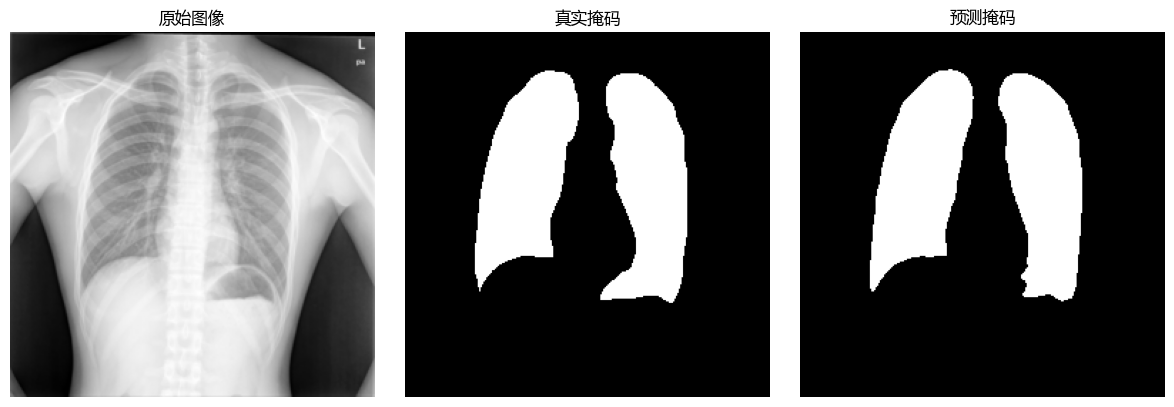

In [15]:
plt.rc("font", family='Microsoft YaHei')
# 从验证集取一个样本进行可视化
model.eval()
sample_img, sample_mask = val_dataset[0]
sample_img_batch = sample_img.unsqueeze(0).to(DEVICE)  # 增加batch维度

with torch.no_grad():
    output = model(sample_img_batch)
    pred_mask = torch.sigmoid(output).cpu().squeeze().numpy()
    pred_mask_binary = (pred_mask > 0.5).astype(np.float32)

# 转换为可显示的格式
img_display = sample_img.squeeze().numpy()
mask_display = sample_mask.squeeze().numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_display, cmap='gray')
plt.title('原始图像')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask_display, cmap='gray')
plt.title('真实掩码')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_mask_binary, cmap='gray')
plt.title('预测掩码')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import random
import matplotlib.pyplot as plt

plt.rc("font", family='Microsoft YaHei')

# 设置随机选择的样本数量
n_samples = 3  # 可修改为你需要的数量

# 获取验证集总长度
dataset_size = len(val_dataset)
if n_samples > dataset_size:
    print(f"警告：n_samples({n_samples})大于验证集大小({dataset_size})，将使用全部样本")
    n_samples = dataset_size

# 随机选择 n 个不重复的索引
random_indices = random.sample(range(dataset_size), n_samples)

model.eval()
# 创建一个足够大的画布，每个样本占一行，每行3列
fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))

# 如果只有一个样本，axes 的维度需要特殊处理，这里统一处理为二维数组
if n_samples == 1:
    axes = axes.reshape(1, -1)

for i, idx in enumerate(random_indices):
    sample_img, sample_mask = val_dataset[idx]
    sample_img_batch = sample_img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(sample_img_batch)
        pred_mask = torch.sigmoid(output).cpu().squeeze().numpy()
        pred_mask_binary = (pred_mask > 0.5).astype(np.float32)

    # 转换为可显示的格式
    img_display = sample_img.squeeze().numpy()
    mask_display = sample_mask.squeeze().numpy()

    # 第一列：原始图像
    axes[i, 0].imshow(img_display, cmap='gray')
    axes[i, 0].set_title(f'原始图像 {i+1}')
    axes[i, 0].axis('off')

    # 第二列：真实掩码
    axes[i, 1].imshow(mask_display, cmap='gray')
    axes[i, 1].set_title(f'真实掩码 {i+1}')
    axes[i, 1].axis('off')

    # 第三列：预测掩码
    axes[i, 2].imshow(pred_mask_binary, cmap='gray')
    axes[i, 2].set_title(f'预测掩码 {i+1}')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()